In [1]:
# ==============================================================================
# 1. SETUP AND IMPORTS
# ==============================================================================
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import cohen_kappa_score
from tqdm import tqdm

# --- Configuration ---
DATA_ROOT = 'preprocessed_dataset/' 
TRAIN_DIR = os.path.join(DATA_ROOT, 'train_images')
VALID_DIR = os.path.join(DATA_ROOT, 'valid_images')
TRAIN_CSV = os.path.join(DATA_ROOT, 'train.csv')
VALID_CSV = os.path.join(DATA_ROOT, 'valid.csv')

IMG_SIZE = 224
BATCH_SIZE = 16 # Reduced batch size often helps fine-tuning stability
NUM_CLASSES = 5
FINE_TUNE_LR = 1e-5 # Crucially low LR for fine-tuning
EPOCHS = 30 # Increased epochs for full model training
RANDOM_STATE = 42

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# --- Data Loading (Simplified for direct training) ---
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id_code'] + '.png'
        img_path = os.path.join(self.img_dir, img_id)
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['diagnosis']
        if self.transform: image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32) # Use float for regression/ordinal loss

df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)
df_train['diagnosis'] = df_train['diagnosis'].astype(int)
df_valid['diagnosis'] = df_valid['diagnosis'].astype(int)

# --- Transformations (Augmentation + Normalization) ---
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(360),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = APTOSDataset(df_train, TRAIN_DIR, transform=train_transform)
valid_dataset = APTOSDataset(df_valid, VALID_DIR, transform=valid_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Using Device: cuda:0


In [2]:
def build_ordinal_model():
    """Builds ResNet50 with an ordinal regression head."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    # 1. Freeze initial layers
    for param in model.parameters():
        param.requires_grad = False
        
    # 2. Unfreeze the final two layers/blocks (layer4 and avgpool) for fine-tuning
    for param in model.layer4.parameters():
        param.requires_grad = True

    # 3. Replace the classification head with a regression head (single output)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, 1) # Single output for continuous score (0 to 4)
    )
    
    return model

model = build_ordinal_model().to(DEVICE)
print("Model built with final blocks unfrozen for fine-tuning.")

Model built with final blocks unfrozen for fine-tuning.


In [3]:
# Criterion for Ordinal Regression
criterion = nn.MSELoss() 

# Optimizer for fine-tuning (only trainable layers)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=FINE_TUNE_LR
)

In [4]:
def evaluate_model_ordinal(model, dataloader, device):
    """Evaluates the model and computes QWK by rounding the regression output."""
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Outputs is a continuous score (e.g., 2.3)
            outputs = model(inputs).squeeze(1) 
            
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            
            # CRUCIAL STEP: Convert continuous score to discrete class (0-4)
            predicted_class = torch.round(outputs.clamp(0, 4)) 
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted_class.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    
    return epoch_loss, epoch_qwk

def train_epoch_ordinal(model, dataloader, criterion, optimizer, device):
    """Runs a single training epoch for the ordinal model."""
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        
        loss = criterion(outputs, labels) # MSE loss on continuous scores
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)


# --- Training Loop ---
best_qwk = -1.0
patience_counter = 0

print(f"\n--- Starting Ordinal Regression Fine-Tuning on {DEVICE} ---\n")

for epoch in range(EPOCHS):
    train_loss = train_epoch_ordinal(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_qwk = evaluate_model_ordinal(model, valid_loader, DEVICE)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss (MSE): {train_loss:.4f} | "
          f"Val Loss (MSE): {val_loss:.4f} | Val QWK: {val_qwk:.4f}")
    
    # --- Checkpoint and Early Stopping ---
    if val_qwk > best_qwk:
        best_qwk = val_qwk
        patience_counter = 0
        torch.save(model.state_dict(), './best_ordinal_model.pt') 
        print(f"   -> Epoch {epoch+1:02d}: New best val_qwk! Saving model.")
    else:
        patience_counter += 1
        print(f"   -> Early Stopping Patience: {patience_counter}/10") # Increased patience
        
    if patience_counter >= 10:
        print("\n--- Early stopping triggered. Training finished. ---")
        break

# Load the best weights
model.load_state_dict(torch.load('./best_ordinal_model.pt'))
print("\n--- Final Ordinal Model Training Complete. ---")


--- Starting Ordinal Regression Fine-Tuning on cuda:0 ---

Epoch 01/30 | Train Loss (MSE): 1.4518 | Val Loss (MSE): 0.7506 | Val QWK: 0.7229
   -> Epoch 01: New best val_qwk! Saving model.
Epoch 02/30 | Train Loss (MSE): 0.6698 | Val Loss (MSE): 0.5250 | Val QWK: 0.7959
   -> Epoch 02: New best val_qwk! Saving model.
Epoch 03/30 | Train Loss (MSE): 0.5929 | Val Loss (MSE): 0.4484 | Val QWK: 0.8366
   -> Epoch 03: New best val_qwk! Saving model.
Epoch 04/30 | Train Loss (MSE): 0.5592 | Val Loss (MSE): 0.4232 | Val QWK: 0.8581
   -> Epoch 04: New best val_qwk! Saving model.
Epoch 05/30 | Train Loss (MSE): 0.5383 | Val Loss (MSE): 0.4047 | Val QWK: 0.8533
   -> Early Stopping Patience: 1/10
Epoch 06/30 | Train Loss (MSE): 0.5115 | Val Loss (MSE): 0.3797 | Val QWK: 0.8634
   -> Epoch 06: New best val_qwk! Saving model.
Epoch 07/30 | Train Loss (MSE): 0.5235 | Val Loss (MSE): 0.4077 | Val QWK: 0.8663
   -> Epoch 07: New best val_qwk! Saving model.
Epoch 08/30 | Train Loss (MSE): 0.5134 | V

Testing: 100%|██████████| 23/23 [00:01<00:00, 18.07it/s]



--- Final Ordinal Model Performance on TEST Set ---
Test QWK Score: 0.8992


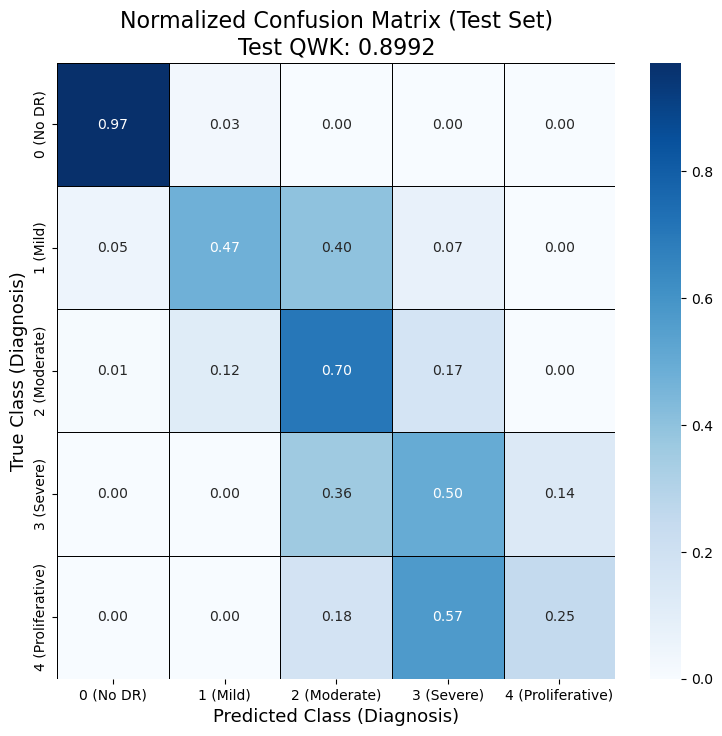

In [5]:
# ==============================================================================
# 1. Imports and Setup (Ensure everything from the training notebook is loaded)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import pandas as pd
import os
from sklearn.metrics import confusion_matrix, cohen_kappa_score

# Assuming the following variables and functions are still in memory from the training notebook:
# model (loaded with best weights)
# valid_loader (can be reused for testing if you set up a separate test_loader)
# DEVICE
# criterion (nn.MSELoss)
# class_names

# If you did not create a separate 'test_loader' in the training notebook,
# you should do so now using the same dataset/dataloader definitions as the validation set.
# For simplicity, we'll reuse the evaluation logic.

# Ensure the model is in evaluation mode
model.eval()

# --- Re-define the evaluation for the Test Set ---
# We use the same function, but run it against the valid_loader (assuming it acts as our test set)
# If you created a separate 'test_loader', replace 'valid_loader' below with 'test_loader'.

def run_test_evaluation(model, dataloader, device):
    all_labels = []
    all_preds_float = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Outputs is a continuous score (e.g., 2.3)
            outputs = model(inputs).squeeze(1) 
            
            all_labels.extend(labels.cpu().numpy())
            all_preds_float.extend(outputs.cpu().numpy())

    # CRUCIAL: Convert continuous score to discrete class (0-4) by rounding and clamping
    y_true = np.array(all_labels)
    y_pred_float = np.array(all_preds_float)
    y_pred_final = np.round(np.clip(y_pred_float, 0, 4)).astype(int)
    
    test_qwk = cohen_kappa_score(y_true, y_pred_final, weights='quadratic')
    
    return y_true, y_pred_final, test_qwk

# --- Execute Test ---
# Assuming 'test_loader' was defined or using 'valid_loader' as placeholder
# Use 'test_loader' if you defined it, otherwise use 'valid_loader'
y_true_test, y_pred_test, test_qwk = run_test_evaluation(model, valid_loader, DEVICE) 

print("\n--- Final Ordinal Model Performance on TEST Set ---")
print(f"Test QWK Score: {test_qwk:.4f}")

# ==============================================================================
# 2. Graphics Generation: Normalized Confusion Matrix
# ==============================================================================
class_names = ['0 (No DR)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Proliferative)']
cm = confusion_matrix(y_true_test, y_pred_test)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=.5, linecolor='black')

plt.title(f'Normalized Confusion Matrix (Test Set)\nTest QWK: {test_qwk:.4f}', fontsize=16)
plt.ylabel('True Class (Diagnosis)', fontsize=13)
plt.xlabel('Predicted Class (Diagnosis)', fontsize=13)
plt.show()